In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["font.sans-serif"] = ["PingFang SC", "Songti SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('VIW_FNT.csv')

In [5]:
df.shape

(178004, 53)

In [6]:
df.isna().sum()

WHOREGION                       0
FLUSEASON                       0
HEMISPHERE                      0
ITZ                             0
COUNTRY_CODE                    0
COUNTRY_AREA_TERRITORY          0
ISO_WEEKSTARTDATE               0
ISO_YEAR                        0
ISO_WEEK                        0
MMWR_WEEKSTARTDATE              0
MMWR_YEAR                       0
MMWR_WEEK                       0
ORIGIN_SOURCE                   0
SPEC_PROCESSED_NB           12210
SPEC_RECEIVED_NB           115900
AH1N12009                   45940
AH1                         78244
AH3                         29960
AH5                        119671
AH7N9                      154834
ANOTSUBTYPED                35181
ANOTSUBTYPABLE             160796
AOTHER_SUBTYPE             131055
AOTHER_SUBTYPE_DETAILS     170664
INF_A                       22824
BVIC_2DEL                  167715
BVIC_3DEL                  168880
BVIC_NODEL                  59633
BVIC_DELUNK                168480
BYAM          

In [7]:
cols_with_na = df.columns[df.isna().any()]
print(cols_with_na)

Index(['SPEC_PROCESSED_NB', 'SPEC_RECEIVED_NB', 'AH1N12009', 'AH1', 'AH3',
       'AH5', 'AH7N9', 'ANOTSUBTYPED', 'ANOTSUBTYPABLE', 'AOTHER_SUBTYPE',
       'AOTHER_SUBTYPE_DETAILS', 'INF_A', 'BVIC_2DEL', 'BVIC_3DEL',
       'BVIC_NODEL', 'BVIC_DELUNK', 'BYAM', 'BNOTDETERMINED', 'INF_B',
       'INF_ALL', 'INF_NEGATIVE', 'ILI_ACTIVITY', 'ADENO', 'BOCA',
       'HUMAN_CORONA', 'METAPNEUMO', 'PARAINFLUENZA', 'RHINO', 'RSV_PROCESSED',
       'RSV', 'OTHERRESPVIRUS', 'OTHER_RESPVIRUS_DETAILS',
       'LAB_RESULT_COMMENT', 'WCR_COMMENT', 'ISO2', 'PSOURCE_SUBTYPE_INF',
       'PSOURCE_PPOS_INF', 'PSOURCE_RSV'],
      dtype='object')


In [8]:
df = pd.read_csv("VIW_FNT.csv", keep_default_na=False, na_values=["", " "])

In [9]:
df.isna().sum()

WHOREGION                       0
FLUSEASON                       0
HEMISPHERE                      0
ITZ                             0
COUNTRY_CODE                    0
COUNTRY_AREA_TERRITORY          0
ISO_WEEKSTARTDATE               0
ISO_YEAR                        0
ISO_WEEK                        0
MMWR_WEEKSTARTDATE              0
MMWR_YEAR                       0
MMWR_WEEK                       0
ORIGIN_SOURCE                   0
SPEC_PROCESSED_NB           12210
SPEC_RECEIVED_NB           115900
AH1N12009                   45940
AH1                         78244
AH3                         29960
AH5                        119671
AH7N9                      154834
ANOTSUBTYPED                35181
ANOTSUBTYPABLE             160796
AOTHER_SUBTYPE             131055
AOTHER_SUBTYPE_DETAILS     170662
INF_A                       22824
BVIC_2DEL                  167715
BVIC_3DEL                  168880
BVIC_NODEL                  59633
BVIC_DELUNK                168480
BYAM          

In [10]:
# 先把计数列转为数值型（float/Int64）
count_cols = [
    "SPEC_RECEIVED_NB","SPEC_PROCESSED_NB",
    "INF_ALL","INF_A","INF_B","INF_NEGATIVE",
    "AH1N12009","AH1","AH3","AH5","AH7N9",
    "ANOTSUBTYPED","ANOTSUBTYPABLE","AOTHER_SUBTYPE",
    "BVIC_2DEL","BVIC_3DEL","BVIC_NODEL","BVIC_DELUNK",
    "BYAM","BNOTDETERMINED",
    "ADENO","BOCA","HUMAN_CORONA","METAPNEUMO",
    "PARAINFLUENZA","RHINO","RSV_PROCESSED",
    "RSV","OTHERRESPVIRUS","ILI_ACTIVITY"
]
count_cols = [c for c in count_cols if c in df.columns]
df[count_cols] = df[count_cols].apply(pd.to_numeric, errors="coerce")

In [11]:
# A / B 细分之和
A_components = ["AH1N12009","AH1","AH3","AH5","AH7N9",
                "ANOTSUBTYPED","ANOTSUBTYPABLE","AOTHER_SUBTYPE"]
A_components = [c for c in A_components if c in df.columns]

B_components = ["BVIC_2DEL","BVIC_3DEL","BVIC_NODEL",
                "BVIC_DELUNK","BYAM","BNOTDETERMINED"]
B_components = [c for c in B_components if c in df.columns]

A_sum = df[A_components].sum(axis=1, min_count=1)

B_sum = df[B_components].sum(axis=1, min_count=1)

In [12]:
# 补 INF_A
mask_inf_a = df["INF_A"].isna() & A_sum.notna()
df.loc[mask_inf_a, "INF_A"] = A_sum[mask_inf_a]

# 补 INF_B
mask_inf_b = df["INF_B"].isna() & B_sum.notna()
df.loc[mask_inf_b, "INF_B"] = B_sum[mask_inf_b]

# 补 INF_ALL
mask_inf_all = df["INF_ALL"].isna() & df["INF_A"].notna() & df["INF_B"].notna()
df.loc[mask_inf_all, "INF_ALL"] = df.loc[mask_inf_all, "INF_A"] + df.loc[mask_inf_all, "INF_B"]

In [13]:
df.isna().sum()

WHOREGION                       0
FLUSEASON                       0
HEMISPHERE                      0
ITZ                             0
COUNTRY_CODE                    0
COUNTRY_AREA_TERRITORY          0
ISO_WEEKSTARTDATE               0
ISO_YEAR                        0
ISO_WEEK                        0
MMWR_WEEKSTARTDATE              0
MMWR_YEAR                       0
MMWR_WEEK                       0
ORIGIN_SOURCE                   0
SPEC_PROCESSED_NB           12210
SPEC_RECEIVED_NB           115900
AH1N12009                   45940
AH1                         78244
AH3                         29960
AH5                        119671
AH7N9                      154834
ANOTSUBTYPED                35181
ANOTSUBTYPABLE             160796
AOTHER_SUBTYPE             131055
AOTHER_SUBTYPE_DETAILS     170662
INF_A                       16306
BVIC_2DEL                  167715
BVIC_3DEL                  168880
BVIC_NODEL                  59633
BVIC_DELUNK                168480
BYAM          

In [14]:
nunique = df.nunique(dropna=False)
nunique

WHOREGION                      6
FLUSEASON                      3
HEMISPHERE                     2
ITZ                           18
COUNTRY_CODE                 187
COUNTRY_AREA_TERRITORY       187
ISO_WEEKSTARTDATE           1587
ISO_YEAR                      31
ISO_WEEK                      53
MMWR_WEEKSTARTDATE          1587
MMWR_YEAR                     31
MMWR_WEEK                     53
ORIGIN_SOURCE                  3
SPEC_PROCESSED_NB           7306
SPEC_RECEIVED_NB            4869
AH1N12009                   1078
AH1                          236
AH3                          961
AH5                           16
AH7N9                          8
ANOTSUBTYPED                1535
ANOTSUBTYPABLE                44
AOTHER_SUBTYPE                25
AOTHER_SUBTYPE_DETAILS        81
INF_A                       2152
BVIC_2DEL                     39
BVIC_3DEL                      7
BVIC_NODEL                   375
BVIC_DELUNK                   86
BYAM                         276
BNOTDETERM

In [15]:
n_rows = len(df)
candidate_id = nunique[nunique == n_rows]
print(candidate_id)

Series([], dtype: int64)


In [16]:
constant_cols = nunique[nunique == 1]
print(constant_cols)

Series([], dtype: int64)


In [17]:
date_cols = ["ISO_WEEKSTARTDATE", "MMWR_WEEKSTARTDATE"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [18]:
# 只把存在于df里的计数列拿出来
count_cols = [c for c in count_cols if c in df.columns]

# 直接转成 pandas 可空整数（能保留缺失值）
df[count_cols] = df[count_cols].astype("Int64")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178004 entries, 0 to 178003
Data columns (total 53 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   WHOREGION                178004 non-null  object        
 1   FLUSEASON                178004 non-null  object        
 2   HEMISPHERE               178004 non-null  object        
 3   ITZ                      178004 non-null  object        
 4   COUNTRY_CODE             178004 non-null  object        
 5   COUNTRY_AREA_TERRITORY   178004 non-null  object        
 6   ISO_WEEKSTARTDATE        178004 non-null  datetime64[ns]
 7   ISO_YEAR                 178004 non-null  int64         
 8   ISO_WEEK                 178004 non-null  int64         
 9   MMWR_WEEKSTARTDATE       178004 non-null  datetime64[ns]
 10  MMWR_YEAR                178004 non-null  int64         
 11  MMWR_WEEK                178004 non-null  int64         
 12  ORIGIN_SOURCE   

In [20]:
iso_dates = df["ISO_WEEKSTARTDATE"]
print(iso_dates.min(), iso_dates.max(), iso_dates.nunique())

1995-01-02 00:00:00 2025-12-01 00:00:00 1587


In [21]:
countries = df["COUNTRY_AREA_TERRITORY"].value_counts()
print(len(countries))        # 187

187


In [22]:
print(countries)

COUNTRY_AREA_TERRITORY
Russian Federation                       2147
Norway                                   1927
Slovenia                                 1901
United States of America                 1899
Germany                                  1898
                                         ... 
Democratic People's Republic of Korea     109
Lesotho                                    40
Congo                                      37
Sudan                                      21
Montserrat                                  1
Name: count, Length: 187, dtype: int64


In [23]:
[c for c in countries.index if "Tai" in c or "tai" in c or "wan" in c]

['Rwanda']

In [24]:
INF_ALL_num = pd.to_numeric(df["INF_ALL"], errors="coerce")
max_inf_all = INF_ALL_num.max()
print(max_inf_all)

56036


In [25]:
rows_max_inf = df[INF_ALL_num == max_inf_all][
    ["COUNTRY_AREA_TERRITORY","ISO_WEEKSTARTDATE","SPEC_PROCESSED_NB","INF_ALL"]
]

In [26]:
rows_max_inf

,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,SPEC_PROCESSED_NB,INF_ALL
163567,United States of America,2025-02-03,178401,56036


In [27]:
INF_A_num = pd.to_numeric(df["INF_A"], errors="coerce")
INF_B_num = pd.to_numeric(df["INF_B"], errors="coerce")

mask_check = INF_ALL_num.notna()
((INF_ALL_num[mask_check] == (INF_A_num.fillna(0)+INF_B_num.fillna(0))[mask_check]).all(), mask_check.sum())

(np.True_, np.int64(162106))

In [28]:
mask_check

0          True
1         False
2          True
3          True
4         False
          ...  
177999    False
178000    False
178001    False
178002    False
178003    False
Name: INF_ALL, Length: 178004, dtype: bool

In [29]:
# df_A = df[A_components].apply(pd.to_numeric, errors="coerce")
# A_sum = df_A.sum(axis=1, min_count=1)

##INF_A vs 各 A 亚型之和

#INF_ALL_num = pd.to_numeric(df["INF_ALL"], errors="coerce")

mask_both_A = INF_A_num.notna() & A_sum.notna()

incons_A = (INF_A_num[mask_both_A] != A_sum[mask_both_A])

mask_both_A.sum(), incons_A.sum()

(np.int64(156544), np.int64(111))

In [30]:
# df_B = df[B_components].apply(pd.to_numeric, errors="coerce")
# B_sum = df_B.sum(axis=1, min_count=1)

mask_both_B = INF_B_num.notna() & B_sum.notna()

incons_B = (INF_B_num[mask_both_B] != B_sum[mask_both_B])

mask_both_B.sum(), incons_B.sum()

(np.int64(152290), np.int64(2187))

In [31]:
print("=== df.info() ===")
df.info()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178004 entries, 0 to 178003
Data columns (total 53 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   WHOREGION                178004 non-null  object        
 1   FLUSEASON                178004 non-null  object        
 2   HEMISPHERE               178004 non-null  object        
 3   ITZ                      178004 non-null  object        
 4   COUNTRY_CODE             178004 non-null  object        
 5   COUNTRY_AREA_TERRITORY   178004 non-null  object        
 6   ISO_WEEKSTARTDATE        178004 non-null  datetime64[ns]
 7   ISO_YEAR                 178004 non-null  int64         
 8   ISO_WEEK                 178004 non-null  int64         
 9   MMWR_WEEKSTARTDATE       178004 non-null  datetime64[ns]
 10  MMWR_YEAR                178004 non-null  int64         
 11  MMWR_WEEK                178004 non-null  int64         
 12

In [32]:
print("\n=== 数值型列 describe() ===")
df.describe().T   # .T 方便按行看每个变量


=== 数值型列 describe() ===


,count,mean,min,25%,50%,75%,max,std
ISO_WEEKSTARTDATE,178004,2016-12-08 13:06:32.269836544,1995-01-02 00:00:00,2012-12-24 00:00:00,2018-04-09 00:00:00,2022-06-06 00:00:00,2025-12-01 00:00:00,NaN
ISO_YEAR,178004.0,2016.454703,1995.0,2012.0,2018.0,2022.0,2025.0,6.755988
ISO_WEEK,178004.0,26.136373,1.0,12.0,26.0,40.0,53.0,15.486511
MMWR_WEEKSTARTDATE,178004,2016-12-07 13:06:32.269836800,1995-01-01 00:00:00,2012-12-23 00:00:00,2018-04-08 00:00:00,2022-06-05 00:00:00,2025-11-30 00:00:00,NaN
MMWR_YEAR,178004.0,2016.453473,1995.0,2012.0,2018.0,2022.0,2025.0,6.75716
MMWR_WEEK,178004.0,26.135699,1.0,12.0,26.0,40.0,53.0,15.486983
SPEC_PROCESSED_NB,165794.0,546.522637,0.0,4.0,29.0,106.0,191785.0,3912.122843
SPEC_RECEIVED_NB,62104.0,937.3175,0.0,11.0,40.0,118.25,191785.0,6065.578676
AH1N12009,132064.0,16.29722,0.0,0.0,0.0,2.0,10575.0,165.307734
AH1,99760.0,0.865066,0.0,0.0,0.0,0.0,906.0,13.113294


In [33]:
# df["ISO_WEEKSTARTDATE"]  = pd.to_datetime(df["ISO_WEEKSTARTDATE"],  errors="coerce")
# df["MMWR_WEEKSTARTDATE"] = pd.to_datetime(df["MMWR_WEEKSTARTDATE"], errors="coerce")

regions = ["AMR", "EUR", "SEAR", "WPR"]
df_4 = df[df["WHOREGION"].isin(regions)].copy()

df["WHOREGION"]
取出 WHOREGION 这一列（每行对应一个区域代码）。

.isin(regions)
判断这一行的区域是否在 regions 这个列表里。返回一串 True/False：

True：该行属于 AMR/EUR/SEAR/WPR 之一

False：不属于（比如 AFR、EMR 等）

df[ ... ]
用布尔条件筛选行：只保留 True 的行。

.copy()
复制一份新 DataFrame，避免后面对 df_4 修改时影响原来的 df，也避免出现 “SettingWithCopyWarning”。

In [34]:
print("四区域合计行数：", len(df_4))
print("四区域国家/地区数：", df_4["COUNTRY_AREA_TERRITORY"].nunique())
print(df_4["WHOREGION"].value_counts())

四区域合计行数： 142833
四区域国家/地区数： 131
WHOREGION
EUR     75063
AMR     39980
WPR     19326
SEAR     8464
Name: count, dtype: int64


In [35]:
latest_year = int(df_4["ISO_YEAR"].max())
df_latest = df_4[df_4["ISO_YEAR"] == latest_year].copy()

In [36]:
print("最近一年：", latest_year)

最近一年： 2025


In [37]:
cum = (df_latest.groupby("COUNTRY_AREA_TERRITORY")[["INF_ALL","INF_A","INF_B"]]
       .sum(min_count=1)
       .rename(columns={
           "INF_ALL":"累积流感数（最近一年）",
           "INF_A":"累积甲流数（最近一年）",
           "INF_B":"累积乙流数（最近一年）"
       }))

In [38]:
cum

,累积流感数（最近一年）,累积甲流数（最近一年）,累积乙流数（最近一年）
COUNTRY_AREA_TERRITORY,,,
Albania,1319,883,436
Argentina,13512,12801,711
Armenia,42,33,9
Australia,14639,12015,2624
Austria,4156,2258,1898
...,...,...,...
United States of America,521064,462471,58593
Uruguay,344,261,83
Uzbekistan,78,7,71


In [39]:
def max_week_and_latest_date(df_region, value_col):
    
    g = df_region.groupby("COUNTRY_AREA_TERRITORY")
    maxv = g[value_col].max()  # 每国历史最大单周值
    
    is_max = df_region[value_col] == g[value_col].transform("max")
    
    # 并列最大时取最晚日期
    max_date = (df_region.loc[is_max]
                .groupby("COUNTRY_AREA_TERRITORY")["ISO_WEEKSTARTDATE"]
                .max()
                .reindex(maxv.index))
    return maxv, max_date

In [40]:
max_all, date_all = max_week_and_latest_date(df_4, "INF_ALL")
max_a,   date_a   = max_week_and_latest_date(df_4, "INF_A")
max_b,   date_b   = max_week_and_latest_date(df_4, "INF_B")

In [41]:
countries = sorted(df_4["COUNTRY_AREA_TERRITORY"].unique())

summary = (pd.DataFrame(index=countries)
           .rename_axis("国家/地区")
           .join(cum, how="left")
           .assign(
               历史最大单周流感数 = max_all,
               历史最大单周甲流数 = max_a,
               历史最大单周乙流数 = max_b,
               历史最大单周流感数对应日期 = date_all,
               历史最大单周甲流数对应日期 = date_a,
               历史最大单周乙流数对应日期 = date_b,
           )
           .reset_index())

In [42]:
summary.head()

,国家/地区,累积流感数（最近一年）,累积甲流数（最近一年）,累积乙流数（最近一年）,历史最大单周流感数,历史最大单周甲流数,历史最大单周乙流数,历史最大单周流感数对应日期,历史最大单周甲流数对应日期,历史最大单周乙流数对应日期
0,Albania,1319,883,436,467,347,121,2025-01-20,2021-12-27,2025-01-20
1,Anguilla,<NA>,<NA>,<NA>,1,1,1,2019-09-23,2019-09-23,2017-02-13
2,Antigua and Barbuda,<NA>,<NA>,<NA>,1,0,1,2018-06-11,2023-09-11,2018-06-11
3,Argentina,13512,12801,711,3438,3438,962,2009-06-29,2009-06-29,2022-11-07
4,Armenia,42,33,9,326,326,35,2016-01-18,2016-01-18,2023-02-27


In [43]:
top5_cum_all = (summary.dropna(subset=["累积流感数（最近一年）"])#"累积流感数（最近一年）"只看这一列是否缺失
                .sort_values("累积流感数（最近一年）", ascending=False)
                .head(5)[["国家/地区","累积流感数（最近一年）","累积甲流数（最近一年）","累积乙流数（最近一年）"]])

In [44]:
top5_cum_all

,国家/地区,累积流感数（最近一年）,累积甲流数（最近一年）,累积乙流数（最近一年）
126,United States of America,521064,462471,58593
24,Canada,132241,116449,15792
27,China,128712,126543,2169
122,"United Kingdom, England",94025,74612,19413
87,Norway,60106,44711,15395


In [45]:
top5_max_all = (summary
                .sort_values("历史最大单周流感数", ascending=False)
                .head(5)[["国家/地区","历史最大单周流感数","历史最大单周流感数对应日期"]])

In [46]:
top5_max_all

,国家/地区,历史最大单周流感数,历史最大单周流感数对应日期
126,United States of America,56036,2025-02-03
27,China,17746,2023-12-04
122,"United Kingdom, England",14701,2022-12-19
24,Canada,11882,2025-02-17
76,Mexico,6738,2009-09-28


1	对累积流感数最多的5个国家，画出累积甲流/乙流数的柱状图，画在一个图上

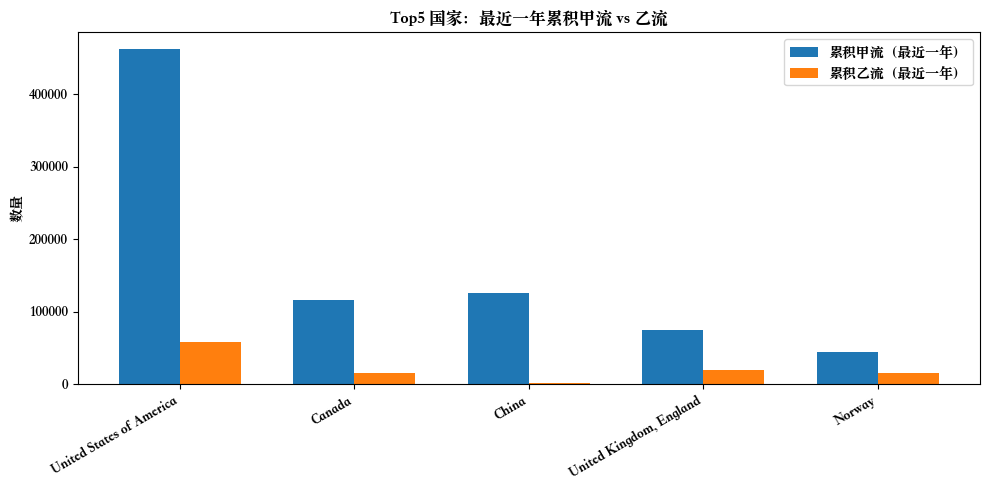

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# 取 Top5（按最近一年累积流感数）
top5 = (summary
        .sort_values("累积流感数（最近一年）", ascending=False)
        .head(5)
        .copy())

countries = top5["国家/地区"].astype(str).tolist()
A = top5["累积甲流数（最近一年）"].astype(float).to_numpy()
B = top5["累积乙流数（最近一年）"].astype(float).to_numpy()

x = np.arange(len(countries))
w = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - w/2, A, width=w, label="累积甲流（最近一年）")
plt.bar(x + w/2, B, width=w, label="累积乙流（最近一年）")
plt.xticks(x, countries, rotation=30, ha="right")
plt.ylabel("数量")
plt.title("Top5 国家：最近一年累积甲流 vs 乙流")
plt.legend()
plt.tight_layout()
plt.show()

2	对历史最大单周流感数最多的5个国家，画出这些国家历史每周流感数线图，画在一个图上

In [48]:
import pandas as pd

country_col = "COUNTRY_AREA_TERRITORY"
date_col = "ISO_WEEKSTARTDATE"
value_col = "INF_ALL"

# 1) 每个国家历史最大单周 INF_ALL（全时间范围）
max_week_all = (df_4.groupby(country_col)[value_col]
                .max()
                .sort_values(ascending=False))

top5_countries = max_week_all.head(5).index.astype(str).tolist()
print("Top5（按历史最大单周 INF_ALL）国家：", top5_countries)
print("对应历史最大单周值：\n", max_week_all.head(5))

# 2) 为画折线准备：Top5 国家“每周 INF_ALL”
# 同一国家同一周如果有多行（不同 ORIGIN_SOURCE），这里先按周加总
weekly_all_top5 = (df_4[df_4[country_col].isin(top5_countries)]
                   .groupby([country_col, date_col])[value_col]
                   .sum(min_count=1)
                   .reset_index()
                   .sort_values([country_col, date_col]))

weekly_all_top5.head()

Top5（按历史最大单周 INF_ALL）国家： ['United States of America', 'China', 'United Kingdom, England', 'Canada', 'Mexico']
对应历史最大单周值：
 COUNTRY_AREA_TERRITORY
United States of America    56036
China                       17746
United Kingdom, England     14701
Canada                      11882
Mexico                       6738
Name: INF_ALL, dtype: Int64


,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,INF_ALL
0,Canada,1996-12-30,<NA>
1,Canada,1997-01-06,174
2,Canada,1997-01-13,157
3,Canada,1997-01-20,93
4,Canada,1997-01-27,81


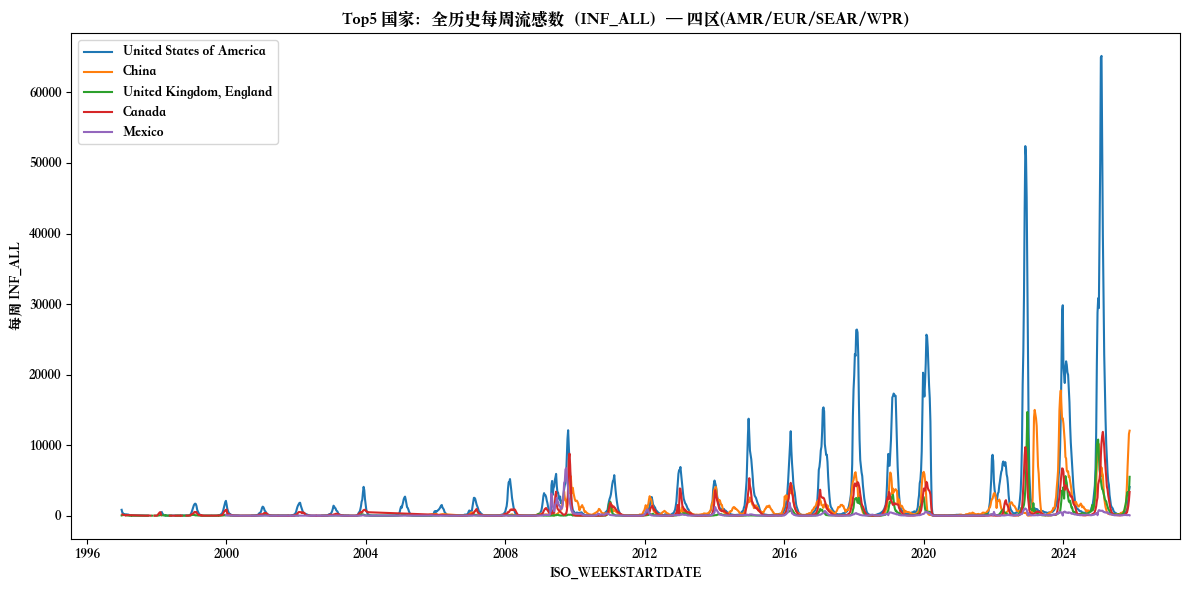

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for c in top5_countries:
    tmp = weekly_all_top5[weekly_all_top5[country_col] == c]
    plt.plot(tmp[date_col], tmp[value_col], label=c)

plt.title("Top5 国家：全历史每周流感数（INF_ALL）— 四区(AMR/EUR/SEAR/WPR)")
plt.xlabel("ISO_WEEKSTARTDATE")
plt.ylabel("每周 INF_ALL")
plt.legend()
plt.tight_layout()
plt.show()


3	画出所有国家累积甲流数、累积乙流数的sns.jointplot，观察两者之间有什么关系

In [50]:
import pandas as pd
import numpy as np

country_col = "COUNTRY_AREA_TERRITORY"

latest_year = int(df_4["ISO_YEAR"].max())  # 近一年（通常就是 2025）
df_1y = df_4[df_4["ISO_YEAR"] == latest_year].copy()

ab = (df_1y.groupby(country_col)[["INF_A","INF_B"]]
      .sum(min_count=1)
      .rename(columns={"INF_A":"A_cum", "INF_B":"B_cum"})
      .dropna())  # 两个都缺的国家就不画

Text(0.5, 1.02, '各国家：近一年(ISO_YEAR=2025)累积甲流 vs 乙流（log1p）')

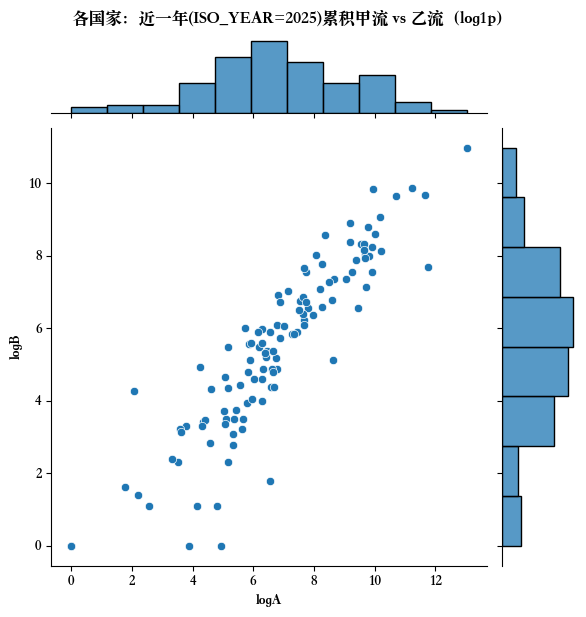

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

ab_plot = ab.copy()
ab_plot["logA"] = np.log1p(ab_plot["A_cum"].astype(float))
ab_plot["logB"] = np.log1p(ab_plot["B_cum"].astype(float))

g = sns.jointplot(data=ab_plot, x="logA", y="logB", kind="scatter", height=6)
g.fig.suptitle(f"各国家：近一年(ISO_YEAR={latest_year})累积甲流 vs 乙流（log1p）", y=1.02)

1.整体呈正相关趋势
甲流累积高的国家，乙流累积往往也不低（监测规模大、流感活动强的国家两者都多）。

2.会有“偏 A 或偏 B”的国家
散点会分布在更靠近 x 轴或 y 轴的位置：
靠 x 轴：乙流少、甲流多（更偏 A）
靠 y 轴：甲流少、乙流多（更偏 B）

3.右上角会有少数离群点
通常是人口大/监测强的国家，把数量级拉开，所以用 log1p 后整体结构更容易看清。

1	观察数据本身、统计结果、可视化结果等，给出观察到的现象，得出一些结论，至少5个结论，每个结论都必须给出数据或图像支撑（可以不限于上述分析内容，比如自己对某个甲流亚型感兴趣，可以额外进行数据分析并得出结论）

结论1: 2025 年总体上 甲流显著多于乙流，但国家差异很大

In [52]:
df_2025 = df_4[df_4["ISO_YEAR"] == latest_year]
tot = df_2025[["INF_ALL","INF_A","INF_B"]].sum()
share_A = tot["INF_A"]/tot["INF_ALL"]
share_B = tot["INF_B"]/tot["INF_ALL"]
tot, share_A, share_B

(INF_ALL    1486573
 INF_A      1248594
 INF_B       237979
 dtype: Int64,
 np.float64(0.8399143533482715),
 np.float64(0.1600856466517285))

结论2：各国“累积甲流 vs 累积乙流”呈强正相关（jointplot 会很明显）

In [53]:
import numpy as np
cum_2025 = df_2025.groupby("COUNTRY_AREA_TERRITORY")[["INF_ALL","INF_A","INF_B"]].sum(min_count=1)
ab = cum_2025[["INF_A","INF_B"]].dropna()
corr_lin = ab.corr().iloc[0,1]
corr_log = np.corrcoef(np.log1p(ab["INF_A"]), np.log1p(ab["INF_B"]))[0,1]
ab.shape, corr_lin, corr_log

((116, 2), np.float64(0.9132278408942693), np.float64(0.9021734333184094))

结论3：2025 年存在明显“季节性峰值”，峰值在 1 月下旬（四区合计）

In [54]:
weekly_total_2025 = df_2025.groupby("ISO_WEEKSTARTDATE")["INF_ALL"].sum(min_count=1).sort_index()
weekly_total_2025.idxmax(), weekly_total_2025.max()

(Timestamp('2025-01-27 00:00:00'), np.int64(125926))

In [55]:
latest_year = int(df_4["ISO_YEAR"].max())
df_2025 = df_4[df_4["ISO_YEAR"] == latest_year]

cum_2025 = df_2025.groupby("COUNTRY_AREA_TERRITORY")[["INF_ALL","INF_A","INF_B"]].sum(min_count=1)
total_2025 = df_2025["INF_ALL"].sum()

top5 = cum_2025.sort_values("INF_ALL", ascending=False).head(5)
top5["INF_ALL"].sum(), total_2025, top5["INF_ALL"].sum()/total_2025

(np.int64(936148), np.int64(1486573), np.float64(0.6297356402948258))

结论5:覆盖国家数随时间显著增加（早期覆盖很少，近年覆盖更全）

In [56]:
countries_per_year = df_4.groupby("ISO_YEAR")["COUNTRY_AREA_TERRITORY"].nunique()
countries_per_year.loc[1995], countries_per_year.max(), countries_per_year.idxmax(), countries_per_year.loc[2025]

(np.int64(3), 127, np.int64(2023), np.int64(116))

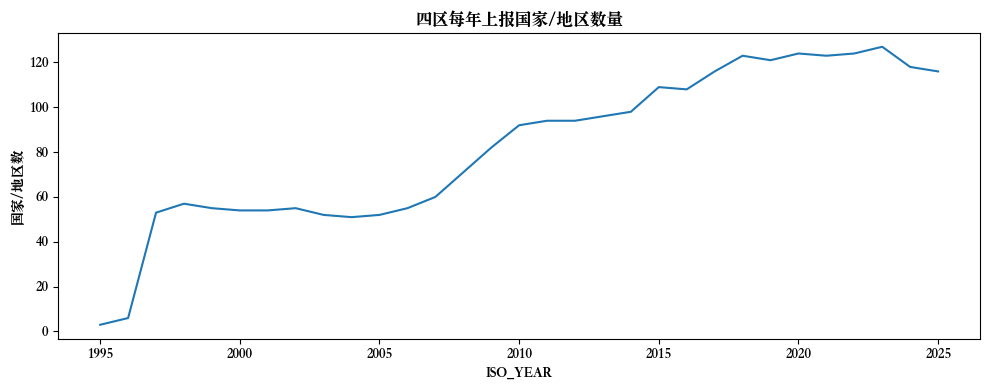

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
countries_per_year.sort_index().plot()
plt.ylabel("国家/地区数")
plt.title("四区每年上报国家/地区数量")
plt.tight_layout(); plt.show()

Top5 国家： ['United States of America', 'China', 'United Kingdom, England', 'Canada', 'Mexico']
绘图使用年份： 2025


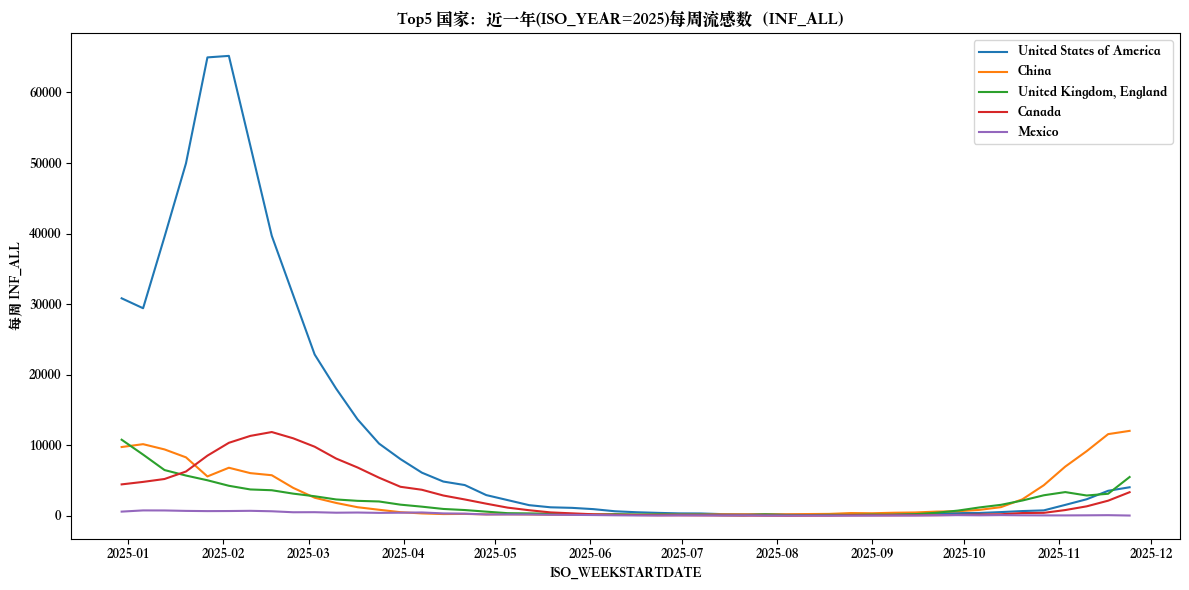

In [58]:
import matplotlib.pyplot as plt

# 1) 用 summary 选出“历史最大单周流感数”Top5 国家
top5_countries = (summary
                  .sort_values("历史最大单周流感数", ascending=False)
                  .head(5)["国家/地区"]
                  .astype(str)
                  .tolist())
print("Top5 国家：", top5_countries)

# 2) 找“最近一年”（用你 summary 里累积列对应的那一年：通常就是 df 的 ISO_YEAR 最大值）
latest_year = int(df["ISO_YEAR"].max())   # 这句只取年份，不做前处理
df_1y = df[df["ISO_YEAR"] == latest_year].copy()
print("绘图使用年份：", latest_year)

# 3) 只保留这 Top5 国家，并按周汇总 INF_ALL（每个国家一条周序列）
df_1y_top = df_1y[df_1y["COUNTRY_AREA_TERRITORY"].isin(top5_countries)].copy()

plt.figure(figsize=(12, 6))
for c in top5_countries:
    s = (df_1y_top[df_1y_top["COUNTRY_AREA_TERRITORY"] == c]
         .groupby("ISO_WEEKSTARTDATE")["INF_ALL"]
         .sum(min_count=1)      # 避免全 NaN 被算成 0
         .sort_index())
    plt.plot(s.index, s.values, label=c)

plt.title(f"Top5 国家：近一年(ISO_YEAR={latest_year})每周流感数（INF_ALL）")
plt.xlabel("ISO_WEEKSTARTDATE")
plt.ylabel("每周 INF_ALL")
plt.legend()
plt.tight_layout()
plt.show()